Device: cuda
GPU   : Tesla T4
=== Path Check ===
  OK      S1Hand                   → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/S1Hand
  OK      LabelHand                → /kaggle/input/datasets/smabrarrajin/sen1floods11-essentials/v1.2/data/flood_events/HandLabeled/LabelHand
  MISSING S1Weak (unlabeled pool)  → None

Converting per-pixel masks → image labels (flooded = water fraction ≥ 0.01) ...
  Chips: 441 (293 flooded | 148 non-flooded)
Labeled split: train 220 (146 flooded) | valid 221 (147 flooded)
  [no S1Weak in this copy → fallback pool]
Labeled train  : 110 chips (72 flooded) after hiding half
Unlabeled pool : 331 chips (110 hidden-label train + 221 valid)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]



resnet18: 11.18M params

Training 200 epochs | alpha 0 → 1.0 (ep 10 → 150) | SGD lr=0.01 | batch 64
Ep[  1/200] α=0.00 │ sup 0.7100 │ unl 0.0000 │ acc  65.16% │ f1  78.06% │ auc 0.5385 │ 42s  ← best
Ep[  2/200] α=0.00 │ sup 0.7320 │ unl 0.0000 │ acc  67.42% │ f1  80.22% │ auc 0.7384 │ 9s  ← best
Ep[  3/200] α=0.00 │ sup 0.6324 │ unl 0.0000 │ acc  70.59% │ f1  80.83% │ auc 0.7812 │ 6s  ← best
Ep[  4/200] α=0.00 │ sup 0.5340 │ unl 0.0000 │ acc  67.87% │ f1  80.33% │ auc 0.8288 │ 6s
Ep[  5/200] α=0.00 │ sup 0.5548 │ unl 0.0000 │ acc  79.64% │ f1  85.05% │ auc 0.8489 │ 6s  ← best
Ep[  6/200] α=0.00 │ sup 0.4893 │ unl 0.0000 │ acc  78.73% │ f1  85.08% │ auc 0.8542 │ 6s  ← best
Ep[  7/200] α=0.00 │ sup 0.4838 │ unl 0.0000 │ acc  67.87% │ f1  69.79% │ auc 0.8493 │ 6s
Ep[  8/200] α=0.00 │ sup 0.4689 │ unl 0.0000 │ acc  80.09% │ f1  83.82% │ auc 0.8653 │ 6s
Ep[  9/200] α=0.00 │ sup 0.3512 │ unl 0.0000 │ acc  78.73% │ f1  85.54% │ auc 0.8706 │ 6s  ← best
Ep[ 10/200] α=0.00 │ sup 0.3944 │ unl 0.

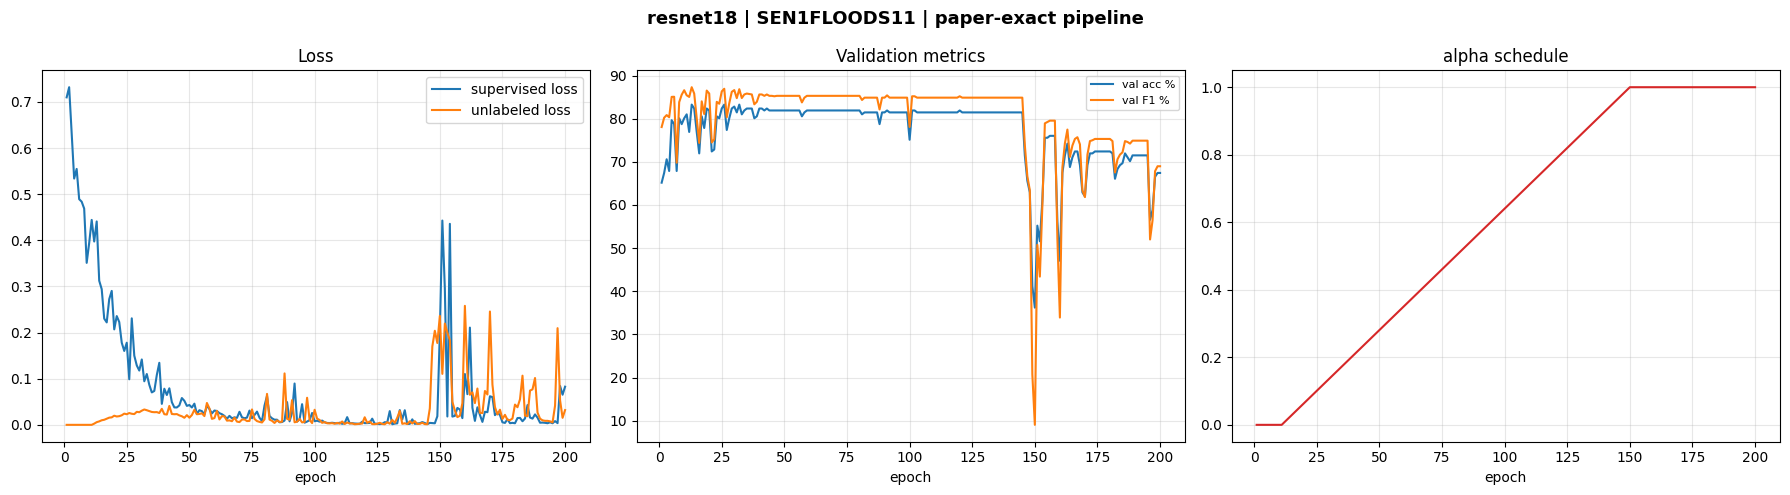

Saved → resnet18_sen1floods11_paper_curves.png

✓ All done.


In [2]:

import os, copy, random, time, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
from pathlib import Path
import rasterio
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import matplotlib.pyplot as plt

# ── 0. Knobs (identical to the FloodNet replication script) ────────────
MODEL_NAME      = "resnet18"  # "resnet18" = paper model | "vgg16" = follow-up
SEED            = 42
IMG_W, IMG_H    = 400, 300    # same input size as the paper pipeline
BATCH           = 64 if MODEL_NAME == "resnet18" else 16
LR              = 0.01        # SGD, no momentum
EPOCHS          = 200
START_ALPHA     = 10
REACH_MAX_ALPHA = 150
MAX_ALPHA       = 1.0
MAX_UNLABELED   = 2000        # ≈ FloodNet pool size (1945)
FLOOD_THRESHOLD = 0.01        # chip flooded if ≥1% valid pixels are water

random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

# ── 1. Locate SEN1FLOODS11 ─────────────────────────────────────────────
ROOT = Path("/kaggle/input/sen1floods11-essentials")
if not ROOT.exists():
    import kagglehub
    ROOT = Path(kagglehub.dataset_download(
        "smabrarrajin/sen1floods11-essentials"))

def find_dir(root, target_name):
    for dirpath, dirnames, _ in os.walk(root):
        for d in dirnames:
            if d.lower() == target_name.lower():
                return Path(dirpath) / d
    return None

S1_DIR    = find_dir(ROOT, "S1Hand")
LABEL_DIR = find_dir(ROOT, "LabelHand")
WEAK_DIR  = find_dir(ROOT, "S1Weak")

print("=== Path Check ===")
for name, p in [("S1Hand", S1_DIR), ("LabelHand", LABEL_DIR),
                ("S1Weak (unlabeled pool)", WEAK_DIR)]:
    print(f"  {'OK' if p else 'MISSING':7} {name:<24} → {p}")
assert S1_DIR is not None and LABEL_DIR is not None

# ── 2. Pixel masks → IMAGE-LEVEL labels ────────────────────────────────
def water_fraction(mask_path):
    """Fraction of VALID pixels (mask != -1) that are water (mask == 1)."""
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    valid = m != -1
    if not valid.any():
        return None
    return float((m[valid] == 1).mean())

print(f"\nConverting per-pixel masks → image labels "
      f"(flooded = water fraction ≥ {FLOOD_THRESHOLD:.2f}) ...")
X, y = [], []
for mask_path in sorted(LABEL_DIR.glob("*.tif")):
    stem    = mask_path.name.replace("_LabelHand.tif", "")
    s1_path = S1_DIR / f"{stem}_S1Hand.tif"
    if not s1_path.exists():
        continue
    wf = water_fraction(mask_path)
    if wf is None:
        continue
    X.append(str(s1_path)); y.append(int(wf >= FLOOD_THRESHOLD))

print(f"  Chips: {len(X)} ({sum(y)} flooded | {len(y)-sum(y)} non-flooded)")

# ── 3. Labeled 50/50 stratified split (exact paper pipeline) ───────────
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, train_size=0.5, stratify=y, random_state=SEED)
print(f"Labeled split: train {len(X_train)} ({sum(y_train)} flooded) | "
      f"valid {len(X_valid)} ({sum(y_valid)} flooded)")

# unlabeled pool = weakly-labeled S1 chips (labels NEVER used)
if WEAK_DIR is not None:
    unlabeled_pool = [str(p) for p in sorted(WEAK_DIR.glob("*.tif"))]
    random.shuffle(unlabeled_pool)
    unlabeled_pool = sorted(unlabeled_pool[:MAX_UNLABELED])
    print(f"Unlabeled pool : {len(unlabeled_pool)} S1Weak chips")
else:
    # FALLBACK — this dataset copy has no S1Weak folder. To keep the
    # semi-supervised pipeline intact (like the paper), build the pool
    # from: (a) half the TRAIN chips with their labels HIDDEN, and
    # (b) the valid chips without labels — the paper did the same thing
    # (their pool included the official Validation + Test images).
    idx = list(range(len(X_train)))
    random.shuffle(idx)
    cut      = int(0.5 * len(idx))
    hidden   = [X_train[i] for i in idx[:cut]]          # labels discarded
    keep     = sorted(idx[cut:])
    X_train  = [X_train[i] for i in keep]
    y_train  = [y_train[i] for i in keep]
    unlabeled_pool = sorted(hidden + list(X_valid))
    print("  [no S1Weak in this copy → fallback pool]")
    print(f"Labeled train  : {len(X_train)} chips "
          f"({sum(y_train)} flooded) after hiding half")
    print(f"Unlabeled pool : {len(unlabeled_pool)} chips "
          f"({len(hidden)} hidden-label train + {len(X_valid)} valid)")

pseudo_labels = np.array([-1] * len(unlabeled_pool))
assert len(unlabeled_pool) > 0, "Unlabeled pool is empty."

# ── 4. SAR chip → 3-channel tensor at 300×400 ──────────────────────────
DB_MIN, DB_MAX = -50.0, 1.0
IMAGENET_MEAN  = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD   = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def load_s1_tensor(path):
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    arr = np.nan_to_num(arr, nan=DB_MIN)
    arr = np.clip(arr, DB_MIN, DB_MAX)
    arr = (arr - DB_MIN) / (DB_MAX - DB_MIN)
    vv, vh = arr[0], arr[1]
    img = np.stack([vv, vh, (vv + vh) / 2.0])
    t = torch.from_numpy(img)
    t = F.interpolate(t.unsqueeze(0), size=(IMG_H, IMG_W),
                      mode="bilinear", align_corners=False).squeeze(0)
    return (t - IMAGENET_MEAN) / IMAGENET_STD

class S1Dataset(Dataset):
    """(img, label) when y given, else (img, index). Random h/v flips
    when augment=True — exactly the paper pipeline's augmentation."""
    def __init__(self, X, y, augment=False):
        self.X, self.y, self.augment = X, y, augment
    def __len__(self): return len(self.X)
    def __getitem__(self, idx):
        t = load_s1_tensor(self.X[idx])
        if self.augment:
            if random.random() < 0.5: t = torch.flip(t, dims=[2])  # horiz
            if random.random() < 0.5: t = torch.flip(t, dims=[1])  # vert
        if self.y is None:
            return t, idx
        return t, self.y[idx]

# weighted sampler (class-balanced batches, exact paper pipeline)
_, counts      = np.unique(y_train, return_counts=True)
class_weights  = [1.0/c for c in counts]
sample_weights = [class_weights[l] for l in y_train]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights),
                                replacement=True)

train_ldr = DataLoader(S1Dataset(X_train, y_train, augment=True),
                       batch_size=BATCH, sampler=sampler,
                       num_workers=2, pin_memory=True)
valid_ldr = DataLoader(S1Dataset(X_valid, y_valid),
                       batch_size=BATCH, shuffle=False,
                       num_workers=2, pin_memory=True)
unlab_ldr = DataLoader(S1Dataset(unlabeled_pool, None),
                       batch_size=BATCH, shuffle=True,
                       num_workers=2, pin_memory=True)

# ── 5. Model: pretrained backbone, 2-logit head, CE, SGD ───────────────
def build_model(name):
    if name == "resnet18":
        m = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1)
        m.fc = nn.Linear(m.fc.in_features, 2)
    elif name == "vgg16":
        m = torchvision.models.vgg16(
            weights=torchvision.models.VGG16_Weights.IMAGENET1K_V1)
        m.classifier[-1] = nn.Linear(4096, 2)
    else:
        raise ValueError(name)
    return m

model = build_model(MODEL_NAME).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"\n{MODEL_NAME}: {n_params/1e6:.2f}M params")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)

# ── 6. Metrics ─────────────────────────────────────────────────────────
def evaluate(model, loader):
    model.eval()
    probs_all, preds_all, lbls_all = [], [], []
    with torch.no_grad():
        for imgs, lbls in loader:
            out   = model(imgs.to(DEVICE))
            probs = torch.softmax(out, 1)[:, 1].cpu().numpy()
            preds = out.argmax(1).cpu().numpy()
            probs_all.extend(probs); preds_all.extend(preds)
            lbls_all.extend(np.asarray(lbls))
    acc  = accuracy_score(lbls_all, preds_all)
    f1   = f1_score(lbls_all,       preds_all, zero_division=0)
    prec = precision_score(lbls_all, preds_all, zero_division=0)
    rec  = recall_score(lbls_all,   preds_all, zero_division=0)
    try:    roc = roc_auc_score(lbls_all, probs_all)
    except: roc = float("nan")
    return acc, f1, prec, rec, roc

# ── 7. Semi-supervised training loop (exact ss_train logic) ────────────
alphas = np.linspace(0, MAX_ALPHA, REACH_MAX_ALPHA - START_ALPHA)

history = []
best_f1, best_epoch, best_state, best_metrics = -1, -1, None, None
CKPT = os.path.join(OUT, f"{MODEL_NAME}_sen1floods11_paper_best.pt")

print(f"\nTraining {EPOCHS} epochs | alpha 0 → {MAX_ALPHA} "
      f"(ep {START_ALPHA} → {REACH_MAX_ALPHA}) | SGD lr={LR} | batch {BATCH}")
print("="*88)
t_start = time.time()

for epoch in range(EPOCHS):
    t0 = time.time()
    if epoch < START_ALPHA:
        alpha = 0.0
    elif epoch - START_ALPHA >= len(alphas):
        alpha = alphas[-1]
    else:
        alpha = alphas[epoch - START_ALPHA]

    # ── phase 1: supervised on labeled train chips ──
    model.train()
    sup_loss, n_b = 0.0, 0
    for imgs, lbls in train_ldr:
        imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(imgs), lbls)
        loss.backward(); optimizer.step()
        sup_loss += loss.item(); n_b += 1

    # ── regenerate pseudo labels (from epoch START_ALPHA-1) ──
    if epoch >= START_ALPHA - 1 and len(unlabeled_pool) > 0:
        model.eval()
        with torch.no_grad():
            for imgs, idxs in unlab_ldr:
                preds = model(imgs.to(DEVICE)).argmax(1).cpu().numpy()
                pseudo_labels[np.asarray(idxs)] = preds

    # ── phase 2: train on pseudo-labeled pool, loss scaled by alpha ──
    unl_loss, n_u = 0.0, 0
    if alpha > 0 and len(unlabeled_pool) > 0:
        model.train()
        for imgs, idxs in unlab_ldr:
            imgs = imgs.to(DEVICE)
            tgts = torch.tensor(pseudo_labels[np.asarray(idxs)],
                                dtype=torch.int64).to(DEVICE)
            optimizer.zero_grad()
            loss = alpha * criterion(model(imgs), tgts)
            loss.backward(); optimizer.step()
            unl_loss += loss.item(); n_u += 1

    # ── phase 3: validate on the held-out labeled chips ──
    acc, f1, prec, rec, roc = evaluate(model, valid_ldr)
    history.append(dict(epoch=epoch+1, alpha=round(alpha,4),
                        sup_loss=round(sup_loss/max(n_b,1),4),
                        unl_loss=round(unl_loss/max(n_u,1),4) if n_u else 0.0,
                        val_acc=round(acc,4), val_f1=round(f1,4),
                        val_precision=round(prec,4), val_recall=round(rec,4),
                        val_auc=round(roc,4)))

    flag = ""
    if f1 > best_f1:
        best_f1, best_epoch = f1, epoch + 1
        best_metrics = (acc, f1, prec, rec, roc)
        best_state = copy.deepcopy(model.state_dict())
        torch.save({"epoch": epoch, "model_state_dict": best_state}, CKPT)
        flag = "  ← best"
    print(f"Ep[{epoch+1:3d}/{EPOCHS}] α={alpha:.2f} │ "
          f"sup {sup_loss/max(n_b,1):.4f} │ "
          f"unl {unl_loss/max(n_u,1) if n_u else 0:.4f} │ "
          f"acc {acc*100:6.2f}% │ f1 {f1*100:6.2f}% │ "
          f"auc {roc:.4f} │ {time.time()-t0:.0f}s{flag}")

    pd.DataFrame(history).to_csv(
        os.path.join(OUT, f"{MODEL_NAME}_sen1floods11_paper_history.csv"),
        index=False)

print("="*88)
print(f"Total time: {(time.time()-t_start)/3600:.2f} h")

# ── 8. Final report ────────────────────────────────────────────────────
model.load_state_dict(best_state)
acc, f1, prec, rec, roc = best_metrics

print("\n" + "═"*64)
print(f"  BEST {MODEL_NAME.upper()} | SEN1FLOODS11 | paper-exact pipeline")
print("═"*64)
print(f"  {'Metric':<12} {'FloodNet paper':>15} {'Ours (SEN1F11)':>16}")
print(f"  {'-'*48}")
print(f"  {'accuracy':<12} {'96.70%':>15} {acc*100:>15.2f}%")
print(f"  {'f1':<12} {'98.10%':>15} {f1*100:>15.2f}%")
print(f"  {'precision':<12} {'—':>15} {prec*100:>15.2f}%")
print(f"  {'recall':<12} {'—':>15} {rec*100:>15.2f}%")
print(f"  {'roc_auc':<12} {'—':>15} {roc*100:>15.2f}%")
print(f"  {'#params':<12} {'11.6M':>15} {n_params/1e6:>14.2f}M")
print(f"  best epoch : {best_epoch}")
print("═"*64)
print("  Compare against the FloodNet replication run of the SAME")
print("  pipeline — a drop here = cross-dataset / modality effect.")

# ── 9. Training curves ─────────────────────────────────────────────────
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"{MODEL_NAME} | SEN1FLOODS11 | paper-exact pipeline",
             fontsize=13, fontweight="bold")

axes[0].plot(hist["epoch"], hist["sup_loss"], label="supervised loss")
axes[0].plot(hist["epoch"], hist["unl_loss"], label="unlabeled loss")
axes[0].set_xlabel("epoch"); axes[0].set_title("Loss"); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist["epoch"], hist["val_acc"]*100, label="val acc %")
axes[1].plot(hist["epoch"], hist["val_f1"]*100,  label="val F1 %")
axes[1].set_xlabel("epoch"); axes[1].set_title("Validation metrics")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

axes[2].plot(hist["epoch"], hist["alpha"], color="tab:red")
axes[2].set_xlabel("epoch"); axes[2].set_title("alpha schedule")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUT, f"{MODEL_NAME}_sen1floods11_paper_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {MODEL_NAME}_sen1floods11_paper_curves.png")
print("\n✓ All done.")
